In [1]:
import os, sys
PROJECT_ROOT = os.getcwd()
sys.path.insert(0, PROJECT_ROOT)

import pickle
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
from cmcrameri import cm

import utils_inverse
import utils_plotting

%load_ext autoreload
%autoreload 2

# Seed uncertainty sweep (Reviewer Point 1) - CO2-only results

Companion notebook for `scripts/6a_seed_uncertainty_sweep.py`. Reproduces the CO2-only quantitative results behind Figures 3 and 4, across 5 independent MLP-init seeds (0-4), reporting mean +/- spread instead of a single-seed point estimate.

**Scope so far**: CO2-only, expensive axis (independent full outer-loop re-optimizations) only. Other agent groups (CH4/N2O/Sulfur/BC/multi-agent) and the cheap axis (emulator-only retrain seeds) are tracked separately in `REVISIONS.md` and not yet included here.

All 30 expensive-axis runs (5 seeds x 6 groups: H-ext, tier1, tier2, DECK, CS3, all) completed with zero NaN/Inf instabilities. The main finding: for every group except `H-ext`, seed-to-seed standard deviation in final loss is comparable to or larger than the mean itself - see the per-panel spread below.

## Figure 3 (CO2 panel): NRMSE vs. optimization step, with seed spread

Recreates the manuscript's `tier1` CO2 panel (loglog training-objective NRMSE vs. outer-loop update step), plus the other 5 experiment groups for additional diagnostic coverage. Each panel shows the mean curve across 5 seeds with a shaded min-max envelope, against the single fixed baseline-emulator reference line used in the original figure.

In [2]:
import importlib.util as _ilu

def _load_experiments_module(path):
    spec = _ilu.spec_from_file_location("_exp_mod", path)
    mod = _ilu.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod

exp_mod = _load_experiments_module(os.path.join(PROJECT_ROOT, "scripts", "3a_inverse_CO2_only.py"))
SEEDS = [0, 1, 2, 3, 4]
GROUPS = list(exp_mod.EXPERIMENTS)  # H-ext, tier1, tier2, DECK, CS3, all

fig3_errors = {}  # group -> (n_seeds, n_steps) array of training-objective NRMSE
for group in GROUPS:
    cfg = exp_mod.EXPERIMENTS[group]
    curves = []
    for seed in SEEDS:
        path = f"checkpoints/co2/seed_sweep/inverse_{cfg['init_cond']}_{cfg['group']}_{cfg['tag']}_seed{seed}.pkl"
        ck = utils_inverse.load_inverse_ckpt(path)
        curves.append(np.asarray(ck["errors"]))
    fig3_errors[group] = np.stack(curves, axis=0)

with open("data/plotting/baseline_co2_only.pkl", "rb") as f:
    baseline_co2 = pickle.load(f)
baseline_ref = baseline_co2["Tier 1"]["mean"]

{g: fig3_errors[g].shape for g in GROUPS}

{'H-ext': (5, 1001),
 'tier1': (5, 1001),
 'tier2': (5, 1001),
 'DECK': (5, 1001),
 'CS3': (5, 1001),
 'all': (5, 1001)}

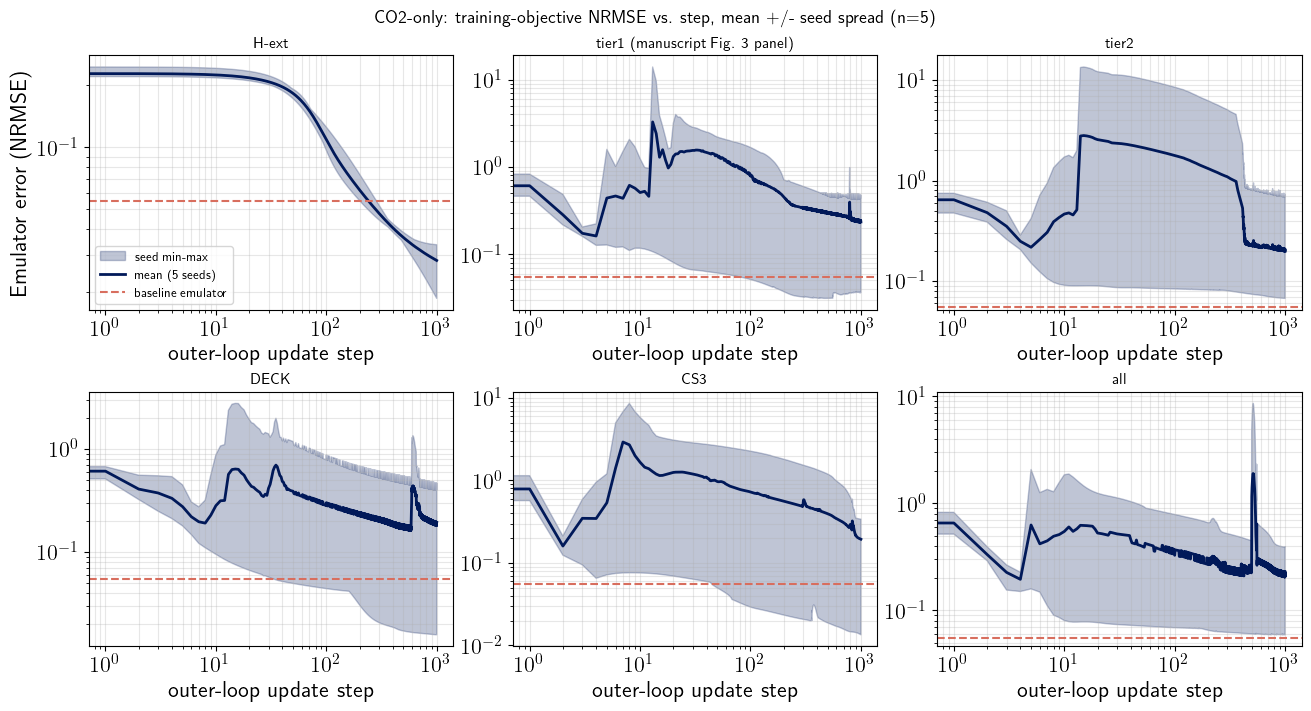

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7), constrained_layout=True)
axes = axes.flatten()
manuscript_group = "tier1"

for ax, group in zip(axes, GROUPS):
    curves = fig3_errors[group]  # (5, n_steps)
    steps = np.arange(curves.shape[1])
    mean_curve = curves.mean(axis=0)
    lo, hi = curves.min(axis=0), curves.max(axis=0)

    ax.fill_between(steps, lo, hi, color=cm.batlowS(0), alpha=0.25, label="seed min-max")
    ax.loglog(steps, mean_curve, color=cm.batlowS(0), lw=2, label="mean (5 seeds)")
    ax.axhline(baseline_ref, ls="--", color=cm.lipariS(5), lw=1.5, label="baseline emulator")

    title = group + ("  (manuscript Fig. 3 panel)" if group == manuscript_group else "")
    ax.set_title(title, fontsize=11, fontweight="bold" if group == manuscript_group else "normal")
    ax.grid(True, alpha=0.3, which="both")
    ax.set_xlabel("outer-loop update step")
    if ax is axes[0]:
        ax.set_ylabel("Emulator error (NRMSE)")
        ax.legend(fontsize=9, loc="best")

plt.suptitle("CO2-only: training-objective NRMSE vs. step, mean +/- seed spread (n=5)", fontsize=13)
plt.show()

## Figure 4, panel (a) CO2-only: performance summary, with seed spread (retuned pipeline)

**2026-08-05 update**: this section now calls `utils_inverse.regenerate_fig4_co2_only_cache_seed_sweep`
and `utils_plotting.plot_grouped_improvement_bars` directly (the real, shared functions) instead of
manually re-implementing the aggregation/bar-chart math, and reads Stage 0b/6e's *retuned* hyperparameter
configs (`best_config_unified.json` / `best_baseline_config_K400.json`) - the same configs
`scripts/0c_regenerate_checkpoints_co2.py`'s multi-seed mode used to produce
`checkpoints/co2_retuned/seed_sweep/`. This also fixes the one methodological gap in the cells below this
one previously had: **the baseline now varies per seed too** (via `run_inverse_experiment_setup`'s
seed-shared-init "fairness property"), rather than dividing every seed's optimized result by one single,
seed-independent baseline.

This supersedes (but does not delete) the older `compute_fig4_eval_spread`/`fig4_eval_spread_3a_inverse_CO2_only.pkl`
path below in Figure 3's section, which is frozen per `REVISIONS.md` (already marked superseded, predates
today's `ema_windows_years` bug fix).

**Requires**: `checkpoints/co2_retuned/seed_sweep/` and a re-run `data/SI_results/hp_retune/best_config_unified.json`
to exist on disk first (Stage 0b re-tune -> Stage 0c multi-seed regeneration, both done on the cluster).

**2026-08-06 update - generation split from loading/plotting**: the cache-generation cell below
(50 seeds x 6 cheap retrains each) is slow enough that it once got killed by `jupyter nbconvert`'s
default per-cell execution timeout mid-run, silently losing an hour of compute with no cache written.
So generation and loading are now two separate cells: the generation cell's actual call is commented
out by default (only uncomment/run it deliberately, e.g. via a standalone background script - see its
own comment - when you need to regenerate after a fresh Stage 0c cluster rerun), and the cell after it
just loads the already-written `data/SI_results/seed_uncertainty/fig4_seed_spread_co2_only.pkl` cache -
fast, and safe to include in a normal top-to-bottom notebook run.</cell id="cell-5">

In [4]:
TRAIN_SCENARIOS = ["Opt. Tier 1", "Opt. Tier 2", "Opt. DECK", "Opt. CS3", "Opt. All"]
TEST_SCENARIOS = ["Tier 1", "Tier 2", "DECK", "CS3"]
WEIGHTS = [7, 5, 2, 2]  # matches Fig 4's original scenario-count weights
FIG4_SEED_SPREAD_CACHE = "data/SI_results/seed_uncertainty/fig4_seed_spread_co2_only.pkl"
SEEDS = list(range(50))  # per user direction (2026-08-05): 50 seeds for the UQ rerun

# --- Cache generation (SLOW - do not run this by default) ---
# ~50 seeds x 6 cheap (K=400) retrains each (1 baseline + 5 fresh evaluation-time emulator
# retrains, one per Opt.-Tier1/Tier2/DECK/CS3/All checkpoint). Only uncomment/run this when you
# need to regenerate the cache below (e.g. after a fresh Stage 0c multi-seed cluster rerun) - the
# next cell just loads the already-written result, which is what a normal top-to-bottom run
# should use. Prefer running this as a standalone background script rather than inside the
# notebook/nbconvert - it once got silently killed by nbconvert's default per-cell execution
# timeout partway through, losing the full run with no cache written (nothing is saved until
# every seed finishes - see regenerate_fig4_co2_only_cache_seed_sweep's docstring):
#
#   python -c "import utils_inverse; utils_inverse.regenerate_fig4_co2_only_cache_seed_sweep(seeds=list(range(50)))"
#
# utils_inverse.regenerate_fig4_co2_only_cache_seed_sweep(seeds=SEEDS, out_path=FIG4_SEED_SPREAD_CACHE)

In [5]:
with open(FIG4_SEED_SPREAD_CACHE, "rb") as f:
    seed_spread = pickle.load(f)

seed_baseline_results = [seed_spread[s]["baseline"] for s in sorted(seed_spread)]
seed_optimized_results = [seed_spread[s]["optimal"] for s in sorted(seed_spread)]

len(seed_baseline_results), len(seed_optimized_results)

(50, 50)

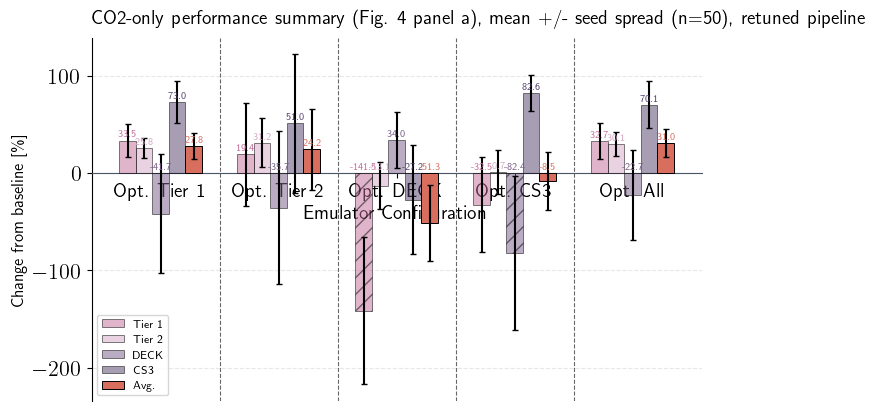

Note: hatching here is applied to the MEAN bar only (matching the manuscript's own +/-60%
rule) - Stage 6f (Point 6) builds the dedicated exact-value transparency table for extreme
per-seed values, not this diagnostic plot.


In [6]:
utils_plotting.plot_grouped_improvement_bars(
    train_scenarios=TRAIN_SCENARIOS,
    test_scenarios=TEST_SCENARIOS,
    x_labels=TRAIN_SCENARIOS,
    leg_labels=TEST_SCENARIOS,
    weights=WEIGHTS,
    seed_baseline_results=seed_baseline_results,
    seed_optimized_results=seed_optimized_results,
    long_title="CO2-only performance summary (Fig. 4 panel a), mean +/- seed spread (n=50), retuned pipeline",
)

print("Note: hatching here is applied to the MEAN bar only (matching the manuscript's own +/-60%")
print("rule) - Stage 6f (Point 6) builds the dedicated exact-value transparency table for extreme")
print("per-seed values, not this diagnostic plot.")

## Notes

- Figure 3's data (above) still comes from the older, frozen exploratory sweep
  (`checkpoints/co2/seed_sweep/`, `expensive_sweep_3a_inverse_CO2_only.csv`) - not yet
  re-run under the retuned/corrected pipeline.
- Figure 4's data (above) now comes from the retuned pipeline:
  `data/SI_results/seed_uncertainty/fig4_seed_spread_co2_only.pkl`, built from
  `checkpoints/co2_retuned/seed_sweep/` + Stage 0b/6e's tuned configs. The older
  `fig4_eval_spread_3a_inverse_CO2_only.pkl` (single shared baseline, un-retuned
  hyperparameters) remains on disk untouched for comparison/archaeology.
- Not yet covered here: CH4/N2O/Sulfur/BC/multi-agent groups (Figs 3/4/6), the cheap axis
  (emulator-only retrain seeds, per the reviewer's "at least emulator-training seeds" ask),
  and Fig 6/7. Tracked in `REVISIONS.md` Stage 6a.
- See `REVISIONS.md`'s session log for the original CO2-only expensive-axis spread numbers
  and the `tier2` seed-1 bad-optimum finding (from the older, un-retuned sweep).
- Once reviewed here, mirror the Figure 4 panel into `5a_paper_plots.ipynb` as one new cell
  appended after its existing Figure 4 cells - not a modification of those cells.